In [15]:
%cd /mnt/sdd1/atharvas/formulacode/datasmith
from pathlib import Path
import pandas as pd
import json

/mnt/sdd1/atharvas/formulacode/datasmith


In [ ]:
all_merged_tasks = pd.read_parquet(Path("scratch/artifacts/pipeflush/merge_commits_filtered_with_patch.parquet"))

all_verified_tasks = json.loads(Path("../terminal-bench/adapters/formulacode/example_task/valid_tasks_200_finished.json").read_text())
repo_sha_valid = set(map(eval, all_verified_tasks.keys()))

In [19]:
repo_sha_valid = set(map(eval, all_verified_tasks.keys()))

# make a tuple of (repo_name, sha) for all_merged_tasks and filter out only those present in repo_sha_valid
all_merged_tasks["repo_sha"] = list(
    zip(all_merged_tasks["repo_name"], all_merged_tasks["sha"])
)
filtered_tasks = all_merged_tasks[
    all_merged_tasks["repo_sha"].isin(repo_sha_valid)
].drop(columns=["repo_sha"])

In [ ]:
# filtered_tasks.to_parquet(
#     Path("scratch/artifacts/pipeflush/merge_commits_filtered_with_patch_valid_tasks_200_finished.parquet")
# )

# Used once when we set all_verified_tasks = json.loads(Path("../terminal-bench/adapters/formulacode/example_task/valid_tasks_200.json").read_text())
# filtered_tasks.to_parquet(
#     Path("scratch/artifacts/pipeflush/merge_commits_filtered_with_patch_valid_tasks_200.parquet")
# )

In [5]:
df = pd.read_parquet(Path("scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_finished.parquet"))

In [22]:
df = pd.read_parquet(Path("scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_all.parquet"))

df[['repo_name']].value_counts()

repo_name                
pandas-dev/pandas            63
Qiskit/qiskit                16
optuna/optuna                 6
UXARRAY/uxarray               2
networkx/networkx             2
geopandas/geopandas           2
xarray-contrib/xbatcher       2
kedro-org/kedro               1
pybop-team/PyBOP              1
pyapp-kit/psygnal             1
scikit-image/scikit-image     1
scikit-learn/scikit-learn     1
shapely/shapely               1
xarray-contrib/flox           1
Name: count, dtype: int64

<Axes: >

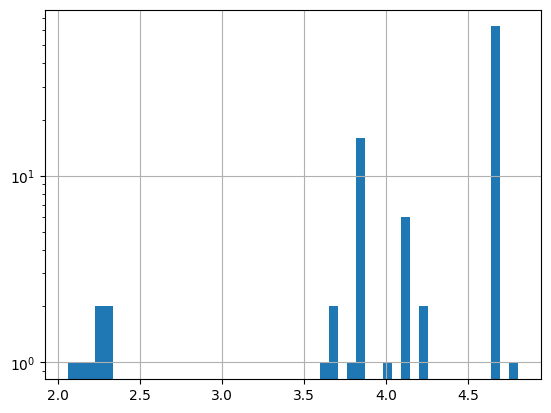

In [30]:
import numpy as np

np.log10(df['pr_base_stargazers_count']).hist(bins=50, log=True)

<Axes: >

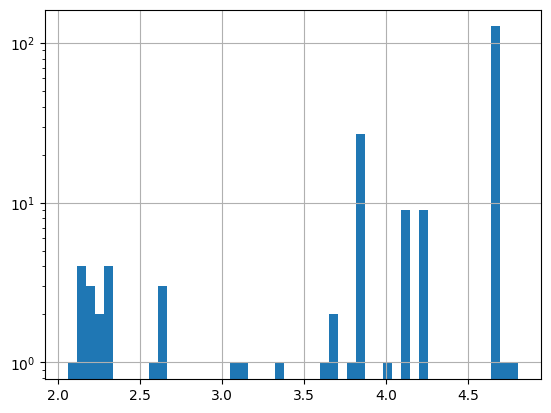

In [16]:
Path("scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_finished.parquet").absolute()

PosixPath('/mnt/sdd1/atharvas/formulacode/datasmith/scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_finished.parquet')

In [17]:
df['classification'].value_counts()

classification
OptimizationType.USE_BETTER_ALGORITHM                    13
OptimizationType.MICRO_OPTIMIZATIONS                     12
OptimizationType.USE_BETTER_DATA_STRUCTURE_AND_LAYOUT     9
OptimizationType.CACHE_AND_REUSE                          4
OptimizationType.USE_PARALLELIZATION                      3
OptimizationType.USE_LOWER_LEVEL_SYSTEM                   3
OptimizationType.USE_HIGHER_LEVEL_SYSTEM                  2
OptimizationType.IO_AND_LATENCY_HIDING                    1
OptimizationType.REMOVE_OR_REDUCE_WORK                    1
Name: count, dtype: int64

In [18]:
df2 = pd.read_parquet(Path("scratch/artifacts/pipeflush/perfonly_commits_with_patch_3.parquet"))

In [21]:
df2['classification'].value_counts()


classification
OptimizationType.MICRO_OPTIMIZATIONS                     467
OptimizationType.USE_BETTER_ALGORITHM                    464
OptimizationType.REMOVE_OR_REDUCE_WORK                   415
OptimizationType.USE_LOWER_LEVEL_SYSTEM                  256
OptimizationType.USE_BETTER_DATA_STRUCTURE_AND_LAYOUT    210
OptimizationType.CACHE_AND_REUSE                         169
OptimizationType.USE_HIGHER_LEVEL_SYSTEM                  78
OptimizationType.USE_PARALLELIZATION                      76
OptimizationType.UNCATEGORIZED                            46
OptimizationType.DO_IT_EARLIER_BATCH_THROTTLE             42
OptimizationType.IO_AND_LATENCY_HIDING                    18
OptimizationType.ACCEPT_LESS_PRECISE_SOLUTION             16
OptimizationType.DATABASE_AND_STORAGE_TUNING              11
Name: count, dtype: int64

What list of tasks do I need to manually review?

In [33]:
all_valid_tasks = pd.read_parquet("scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_all.parquet")

all_finished_tasks = pd.read_parquet("scratch/artifacts/pipeflush/perfonly_commits_with_patch_valid_tasks_200_finished.parquet")

all_finished_tasks.shape, all_valid_tasks.shape

((48, 161), (100, 161))

In [41]:
remaining_tasks = all_valid_tasks.merge(
    all_finished_tasks[["repo_name", "pr_base_sha"]],
    on=["repo_name", "pr_base_sha"],
    how="left",
    indicator=True,
)
remaining_tasks = remaining_tasks[remaining_tasks["_merge"] == "left_only"]
remaining_tasks['done'] = False
remaining_tasks[['repo_name', 'pr_base_sha', 'done']].to_csv("dataset/pending_manual_review_tasks.csv", index=False)